# Shear Wall design ACI 318-19

**Define concrete and steel materials, and then assign the shear wall**

In [5]:
# from mento import Concrete_ACI_318_19, SteelBar, ShearWall, cm, kN, MPa, m
from mento import Concrete_CIRSOC_201_25, SteelBar, ShearWall, cm, kN, MPa, m
from mento import Forces, Node

# Define materials
concrete = Concrete_CIRSOC_201_25(name="C25", f_c=25 * MPa)
steel = SteelBar(name="ADN 420", f_y=420 * MPa)

# Define wall geometry:
wall = ShearWall(
    label="W1", concrete=concrete, steel_bar=steel, thickness=20 * cm, length=4.0 * m, height=3.5 * m, c_c=2.0 * cm
)
wall.data

Shear Wall W1, $l_w$=400.00 cm, $t$=20.00 cm, $h_w$=350.00 cm, $c_c$=2.00 cm, Concrete C25, Rebar ADN 420.

**Define list of forces applied to the wall and create node**

In [6]:
# Define forces acting on the wall
f1 = Forces(label="1.2D+1.0E", V_z=800 * kN)
f2 = Forces(label="0.9D+1.0E", V_z=500 * kN)
# Create node with wall and forces
node_1 = Node(section=wall, forces=[f1, f2])
node_1

Node ID: 2 - Section label: W1
Forces Applied:
  - Force ID: 3, Label: 1.2D+1.0E, N_x: 0.00 kN, V_z: 800.00 kN, M_y: 0.00 kN·m
  - Force ID: 4, Label: 0.9D+1.0E, N_x: 0.00 kN, V_z: 500.00 kN, M_y: 0.00 kN·m

**Perform shear design**

In [7]:
# Perform design
node_1.design()
# Print results in Markdown format
node_1.results

Shear Wall W1, $l_w$=400.00 cm, $t$=20.00 cm, $h_w$=350.00 cm, $c_c$=2.00 cm, Concrete C25, Rebar ADN 420.

Horizontal rebar: Ø8/20 cm E.F., $\rho_t$=0.00251, Minimum vertical rebar: Ø10/30 cm E.F., $\rho_l$=0.00262, $V_u$=800 kN, $\phi V_n$=1383.35 kN → $\color{#439b00}{\text{DCR}=0.58}$ 

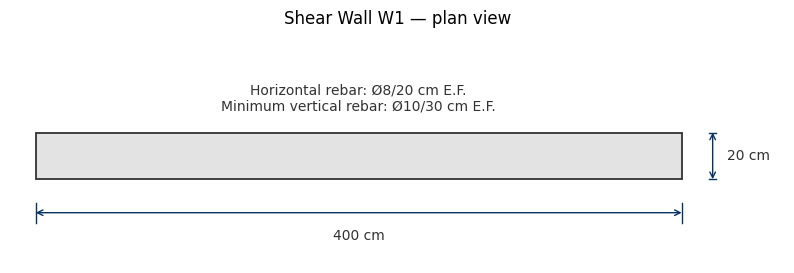

In [8]:
# Plot the wall geometry and reinforcement
wall.plot()

In [9]:
# Print shear results in more detailed format in a DataFrame
node_1.check_shear()

,Label,Comb.,"ρt,min","ρt,req",ρt,"ρl,min",ρl,Vu,ØVc,ØVs,ØVn,"ØVn,max","Vu≤ØVn,max",Vu≤ØVn,DCR
0,,,,,,,,kN,kN,kN,kN,kN,,,
1,W1,1.2D+1.0E,0.0025,0.0025,0.00251,0.0025,0.00262,800,750.0,633.35,1383.35,1980.0,True,True,0.578
2,W1,0.9D+1.0E,0.0025,0.0025,0.00251,0.0025,0.00262,500,750.0,633.35,1383.35,1980.0,True,True,0.361


**Export table results to Excel**

In [10]:
node_1.check_shear().to_excel("ACI 318-19 shear_wall_results.xlsx")

**View complete and detailed results for the limiting case of the list of forces**

In [11]:
# View detailed shear results
node_1.shear_results_detailed()

===== SHEAR WALL DETAILED RESULTS =====
Materials                            Variable     Value  Unit
----------------------------------  ----------  -------  ------
Section Label                                        W1
Concrete strength                       fc           25  MPa
Steel reinforcement yield strength      fy          420  MPa
Normalweight concrete                   λ             1
Safety factor for shear                 Øv         0.75 

Geometry           Variable     Value  Unit
----------------  ----------  -------  ------
Wall thickness        t            20  cm
Wall length           lw          400  cm
Wall height           hw          350  cm
Aspect ratio        hw/lw       0.875
Gross shear area     Acv         8000  cm² 

Design forces     Variable     Value  Unit
---------------  ----------  -------  ------
Shear                Vu          800  kN 

Check                            Unit     Value  Min.    Max.     Ok?
------------------------------  ------  --

**Export detailed results to a Word document**

In [12]:
node_1.shear_results_detailed_doc()